# Inter-rater reliability Script


Takes in a folder of csv files from ELAN, with file names {video_name}_ {initials}. Standardizes behavior names to "allogrooming", "allolicking", and "self licking". Outputs corrleational matrix between each person (for all videos together) and ICC score.

**folder of csv data must be in same directory as this jupyter notebook, change folder path if needed**

In [1]:
#Import necessary libraries
import pandas as pd
import numpy as np
import pingouin as pg
from sklearn.metrics import cohen_kappa_score
import os
import re
import seaborn as sns
import matplotlib.pyplot as plt

In [12]:
# assuming all data is in same folder as this file, with folder name 'csv'
folder_path = r"/Volumes/Lab/2025-07_AnalysisWorkshop/reliability"
#Input initials of the user to compare all other scores against
initial_1 = "AN" 

In [13]:
#Create function to standardize behavior names
def standardize(x):
    '''
    takes a column of text, and standardizes it to all lowercase, no spaces, no punctuation/non-alphanumeric characters
    '''
    # Remove all non-alphanumeric characters (punctuation, spaces, etc.)
    label_cleaned = re.sub(r'[^a-zA-Z]', '', x)
    # Convert to lowercase
    label_standardized = label_cleaned.lower()
    
#    if 'self' in label_standardized:
#        label_standardized = 'selflicking'
#    elif 'groom' in label_standardized:
#        label_standardized = 'allogrooming'
#    else:
#        label_standardized = 'allolicking'
#    
    return label_standardized

In [15]:
#Create data frames from each csv and initiate pairwise ICC comparisons

# dictionary to hold all the data that will be turned into final df
all_video_data = {}
large_df = pd.DataFrame()
all_initials = set()

# loop through each file 
for filename in os.listdir(folder_path):
    
    if filename.endswith('.csv'):  # Check if the file is a CSV
        file_path = os.path.join(folder_path, filename)
        
        # temp dictionary that'll be added to all_video_data at the end of the loop
        curr_vid_data = {}
        
        # extract initials and file name for labeling purposes
        initials = filename.strip('.csv')[-2:]
        video_name = filename.split('_')[0]

        all_initials.add(initials)

    
   
        # turn current csv file into a data frame
        df = pd.read_csv(file_path, header = None)
        
        # standardize the labeling to all lowercase and no spaces/punctuation
        df[0] = df[0].apply(standardize)
        
        # get the total duration of each behavior
        # 0 = behavior name
        # 1 = NaN column
        # 2 = start time
        # 3 = end time
        # 4 = duration
        # 5 = NaN column
        
        d = dict(df.groupby(0).sum()[4])
        
        # rename the keys using initial and behavior name ex) allogrooming_KT
        for key, value in d.items():
            curr_vid_data[f'{key}_{initials}'] = value
        
        
        # first time this video appears,  not yet in large dict (creates new row for the video)
        if video_name not in all_video_data:
            all_video_data[video_name] = curr_vid_data  
            
        # video already in the dictonary, just append the data to existing row
        else:
            all_video_data[video_name].update(curr_vid_data)      
        

# Create a dataframe per behavior with column = initials, rows = video and values = total duration of behavior
reliability_df = pd.DataFrame(all_video_data).T.sort_index().fillna(0)

# Create all pairwise comparisons of unique values in a list
initials_list = list(all_initials)
pairwise_comparisons = [(g1, g2) for i, g1 in enumerate(initials_list) for g2 in initials_list[i+1:]]
output = {}
behaviors = ['allogrooming', 'allolicking', 'selflicking']

for behavior in behaviors:
#     print(f'{behavior}')
    col = [i for i in reliability_df.columns if behavior in i]
    behavior_df = reliability_df[col]
    behavior_df.columns = behavior_df.columns.str[-2:]
#     raters = df_wide.columns
    
    icc_results = {}
    
    for rater in behavior_df.columns:
        if rater != initial_1:
            temp_df = behavior_df[[initial_1, rater]].reset_index()  # Ensure video names are included
            temp_df = temp_df.melt(id_vars="index", var_name="Rater", value_name="Score")

            icc_result = pg.intraclass_corr(data=temp_df, targets='index', raters='Rater', ratings='Score')
            icc_value = icc_result[icc_result['Type'] == 'ICC2']['ICC'].values[0]
            icc_results[rater] = icc_value  # Store the ICC value
    
    output[behavior] = icc_results

    # Convert to DataFrame
    icc_df = pd.DataFrame.from_dict(icc_results, orient='index', columns=[f'ICC with {initial_1} for {behavior}']).reset_index()

    # Print ICC values
    print(icc_df)

  index  ICC with AN for allogrooming
0    DS                      0.825889
1    BF                      0.963308
2    RB                      0.977968
3    AB                      0.697549
4    MW                      0.977505
5    KT                      0.792391
6    KC                      0.578569
7    NK                      0.991274
8    MR                      0.764881
  index  ICC with AN for allolicking
0    DS                     0.995818
1    BF                     0.988984
2    MA                     0.918308
3    RB                     0.997820
4    AB                     0.997003
5    MW                     0.997772
6    KT                     0.986606
7    KC                     0.993946
8    NK                     0.997791
9    MR                     0.998413
  index  ICC with AN for selflicking
0    DS                     0.690158
1    BF                     0.919575
2    MA                    -0.041564
3    RB                     0.974319
4    AB                     

ICC Score Comparison against AN


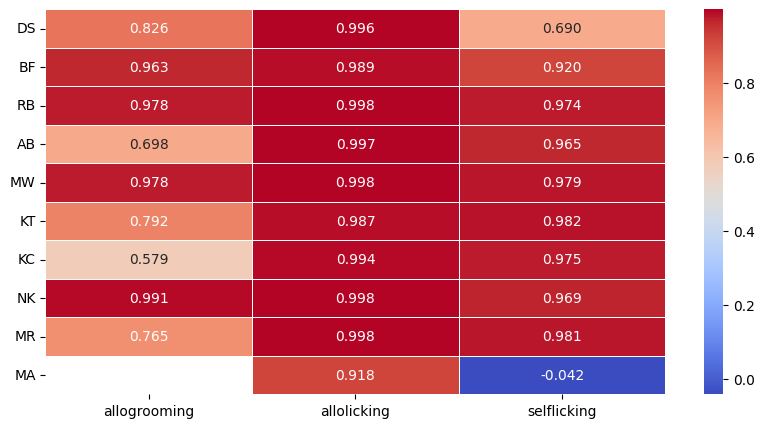

In [11]:
#Plot ICC result heat map
r = pd.DataFrame(output)
print(f"ICC Score Comparison against {initial_1}")
plt.figure(figsize=(10, 5));
sns.heatmap(r, annot = True, cmap = "coolwarm", linewidths=0.5, fmt=".3f");  
plt.yticks(rotation=0);